# 📊 VPR evaluation — MegaLoc, TextInPlace, and the pipeline

This notebook evaluates the retrieval paths of this repository on one shared database/query split,
under one metric definition. That fixes a real problem: `test_megaloc.py` and `test_textinplace.py`
default to different correctness radii and `vpr_pipeline` hard-codes 25 m, so their printed numbers
cannot be read side by side even for the *same* model.

**It does not rank MegaLoc against TextInPlace.** They target different problems — a general-purpose
global retriever versus a scene-text-assisted one — so each family gets its own table in section 5,
and comparisons stay inside a family (released checkpoint vs local training, with and without text
re-ranking).

| Section | What it does |
|---|---|
| 1 | Builds the shared database / query split from the GSV-Cities test CSV |
| 2 | MegaLoc — global descriptor retrieval |
| 3 | TextInPlace — released vs local checkpoint, with and without text re-ranking |
| 4 | `vpr_pipeline` — agreement check: same weights through the production FAISS path |
| 5 | Per-family result tables + charts |
| 6 | Single-image inference demo  |
| 7 | Optional fine-tuning smoke test (why a single photo cannot be "trained on") |

**Everything degrades gracefully**: a missing checkpoint or an uninstalled dependency
(Detectron2, LightGlue, Ollama) skips that section instead of breaking the notebook.

Prerequisites — see [README.md](README.md):

```bash
pip install torch torchvision faiss-cpu pandas numpy pillow tqdm matplotlib
```

## ⚙️ 0. Configuration

Edit the paths below to match your machine. `MAX_PLACES` caps the number of places loaded so a
first pass finishes in minutes; set it to `None` for the full evaluation.

In [41]:
from pathlib import Path

# --- Paths -----------------------------------------------------------------
REPO_ROOT = Path.cwd()
DATASET_ROOT = Path("/media/rayan/usb/VPR Dataset/paris/gsv_cities")
MEGALOC_WEIGHTS = REPO_ROOT / "MegaLoc" / "Results" / "trainings" / "megaloc_finetuned_paris.pth"
TEXTINPLACE_WEIGHTS = REPO_ROOT / "TextInPlace" / "weights" / "textinplace_finetuned.pth"
QUERY_IMAGE = REPO_ROOT / "Test pics" / "screen3.png"
# Ground truth of the query, for the map in section 6: (lat, lon), or None to read it
# from the image EXIF. IMG_0733.png has no EXIF — the PNG conversion stripped it.
QUERY_TRUE_LATLON = None

# --- Evaluation settings ---------------------------------------------------
SPLIT = "test"          # "test" -> <City>_test.csv when present, else <City>.csv
MAX_PLACES = None       # full test split (was capped at 200 places for a quick first pass —
                        # the MegaLoc descriptor cache now makes the full run cheap on repeat)
K_VALUES = (1, 5, 10)
DIST_THRESHOLDS = (25.0, 100.0)   # 25 m = vpr_pipeline, 100 m = test_*.py default
BATCH_SIZE = 16         # batched descriptor extraction (MegaLoc only)
RANK_TOP_K = 100        # candidates kept per query (R@10 needs 10, the text re-rank 100)
RANK_BLOCK = 512        # queries per similarity GEMM — see rank_by_cosine()

# --- Optional stages -------------------------------------------------------
RUN_TEXTINPLACE = True      # needs TextInPlace/repo + Detectron2 + weights
RUN_PIPELINE = True         # needs faiss
PIPELINE_IN_TABLE = False   # see section 4 — it is the same model, not a competitor
PIPELINE_MAX_QUERIES = 200  # agreement check runs on a sample; None = every query
USE_OCR_IN_DEMO = False     # needs TextInPlace + a running Ollama server
USE_RANSAC_IN_DEMO = True   # needs lightglue

# --- TextInPlace: descriptor pass ------------------------------------------
# The checkpoint was fine-tuned at 320 px, so the descriptor is extracted at 320 px.
TEXTINPLACE_VPR_INPUT_SIZE = 320

# Released TextInPlace checkpoint (16384-d, properly initialised spotter), scored as a
# same-family baseline: the local training never loads it, so the two are independent runs.
TEXTINPLACE_UPSTREAM_WEIGHTS = REPO_ROOT / "TextInPlace" / "repo" / "checkpoints" / "best_model.pth"
RUN_TEXTINPLACE_UPSTREAM = True

# --- TextInPlace: scene-text pass ------------------------------------------
# Separate pass, because the text branch only works under conditions that would
# invalidate the descriptor (see section 3):
#   * the spotter must be initialised from Bridge_tt.pth — the local checkpoint
#     carries a randomly initialised one (Base.yaml sets no MODEL.WEIGHTS);
#   * 1000 px input: at 320 px nothing is detected even with correct weights;
#   * threshold 0.15: scores peak at 0.2-0.3, under the config's 0.4.
TEXTINPLACE_OCR = True
TEXTINPLACE_OCR_INPUT_SIZE = 1000
TEXTINPLACE_OCR_THRESHOLD = 0.15
TEXTINPLACE_SPOTTER_WEIGHTS = REPO_ROOT / "TextInPlace" / "repo" / "checkpoints" / "Bridge_tt.pth"

# rank_by_cosine() only keeps RANK_TOP_K candidates per query, and evaluate() reads
# ranking[:, :max(K_VALUES)] — fewer columns than that would silently understate Recall
# instead of raising. Clamp here, once, where both constants are already in scope.
if RANK_TOP_K < max(K_VALUES):
    print(f"RANK_TOP_K={RANK_TOP_K} < max(K_VALUES)={max(K_VALUES)} -> raised to {max(K_VALUES)}.")
    RANK_TOP_K = max(K_VALUES)

for label, path in [("dataset", DATASET_ROOT), ("MegaLoc weights", MEGALOC_WEIGHTS),
                    ("TextInPlace weights", TEXTINPLACE_WEIGHTS), ("query image", QUERY_IMAGE)]:
    print(f"{'OK  ' if path.exists() else 'MISS'}  {label:20s} {path}")

OK    dataset              /media/rayan/usb/VPR Dataset/paris/gsv_cities
OK    MegaLoc weights      /home/rayan/Documents/github/Visual Place Recognition/MegaLoc/Results/trainings/megaloc_finetuned_paris.pth
OK    TextInPlace weights  /home/rayan/Documents/github/Visual Place Recognition/TextInPlace/weights/textinplace_finetuned.pth
OK    query image          /home/rayan/Documents/github/Visual Place Recognition/Test pics/screen3.png


### Shared helpers

`gsv_cities.py` (path resolution) is loaded straight from `MegaLoc/lib/` by file path rather than
by package import: `MegaLoc/lib/` and `TextInPlace/lib/` are two different folders with the same
`lib` package name, and importing both the normal way would shadow one another.

In [42]:
import importlib.util
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import torchvision.transforms as T
from PIL import Image
from tqdm.auto import tqdm

# The repository root must be importable for `vpr_pipeline.*`
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def load_module(path, name):
    """Import a .py file directly, bypassing package-name collisions."""
    spec = importlib.util.spec_from_file_location(name, str(path))
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


gsv = load_module(REPO_ROOT / "MegaLoc" / "lib" / "gsv_cities.py", "vpr_nb_gsv_cities")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")


def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres (vectorised over numpy arrays)."""
    R = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(np.asarray(lat2) - np.asarray(lat1))
    dl = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

Device: cuda
GPU   : NVIDIA GeForce RTX 4090


## 1️⃣ Shared database / query split

Same protocol as `test_megaloc.py` and `test_textinplace.py`: for every `place_id`, the **first**
image becomes the database reference and the remaining ones become queries. Places holding a
single image stay in the database as distractors. Places are keyed by `(source, place_id)` so
`place_id`s coming from two different dataset roots can never collide.

> ⚠️ With `MAX_PLACES` set, the database is truncated too — fewer distractors means an easier
> retrieval task, so absolute Recall values will be optimistic. Comparisons *between* models stay
> valid because all of them see the exact same split.

In [43]:
def build_split(dataset_root, split="test", max_places=None):
    """Return (db_entries, query_entries), both lists of dicts."""
    specs = gsv.discover_csvs(str(dataset_root), split=split)
    if not specs:
        raise FileNotFoundError(f"No CSV found under {dataset_root}/Dataframes")

    db, queries = [], []
    for source_idx, (csv_path, img_dir) in enumerate(specs):
        print(f"  source {source_idx}: {Path(csv_path).name}")
        df = pd.read_csv(csv_path, dtype={"panoid": str})
        for pid, group in df.groupby("place_id"):
            if max_places is not None and len(db) >= max_places:
                break
            resolved = []
            for _, row in group.iterrows():
                path = gsv.resolve_image_path(img_dir, row)
                if path is not None:
                    resolved.append((row, path))
            if not resolved:
                continue

            key = f"{source_idx}:{pid}"
            row, path = resolved[0]
            db.append({"path": path, "place_id": key,
                       "lat": float(row["lat"]), "lon": float(row["lon"])})
            for row, path in resolved[1:]:
                queries.append({"path": path, "place_id": key,
                                "lat": float(row["lat"]), "lon": float(row["lon"])})
    return db, queries


t0 = time.time()
DB, QUERIES = build_split(DATASET_ROOT, split=SPLIT, max_places=MAX_PLACES)
print(f"\nDatabase : {len(DB)} places")
print(f"Queries  : {len(QUERIES)} images")
print(f"Built in {time.time() - t0:.1f}s")

DB_LATS = np.array([e["lat"] for e in DB])
DB_LONS = np.array([e["lon"] for e in DB])
DB_PLACES = np.array([e["place_id"] for e in DB])
PATH_TO_IDX = {e["path"]: i for i, e in enumerate(DB)}

  source 0: Paris_test.csv

Database : 3926 places
Queries  : 22907 images
Built in 2.2s


### Recall@K

A prediction counts as correct when the `place_id` matches **or** the ground-truth GPS distance is
within the threshold. `RESULTS` accumulates every scored run and `META` keeps a one-line note per
run (descriptor size, timing) for the legend under its family's table.

In [44]:
RESULTS = {}   # name -> {"R@1 (25m)": 0.42, ...}
META = {}      # name -> short description shown under its table
FAMILY = {}    # name -> model family; results are only ever tabulated within a family


def evaluate(ranking, queries, k_values=K_VALUES, thresholds=DIST_THRESHOLDS,
             name=None, note=None, family=None, verbose=True):
    """ranking: int array [n_queries, >= max(k_values)] of database row indices."""
    ranking = np.asarray(ranking)
    scores = {}
    for thr in thresholds:
        counts = {k: 0 for k in k_values}
        for qi, q in enumerate(queries):
            top = ranking[qi, : max(k_values)]
            dists = haversine_m(q["lat"], q["lon"], DB_LATS[top], DB_LONS[top])
            correct = (DB_PLACES[top] == q["place_id"]) | (dists <= thr)
            for k in k_values:
                if correct[:k].any():
                    counts[k] += 1
        for k in k_values:
            scores[f"R@{k} ({thr:.0f}m)"] = counts[k] / len(queries)

    if name:
        RESULTS[name] = scores
        if note:
            META[name] = note
        FAMILY[name] = family or name
        if verbose:
            print(f"\n{name}")
            print("-" * len(name))
            for metric, value in scores.items():
                print(f"  {metric:14s} = {value * 100:6.2f} %")
    return scores


def rank_by_cosine(query_desc, db_desc, top_k=RANK_TOP_K, block=RANK_BLOCK):
    """Top-K candidates per query — (indices [n, K] int32, scores [n, K] float32).

    Ranking the *whole* database per query does not scale: on the full split
    (22,907 queries x 3,926 places) a complete argsort keeps 719 MB of indices plus
    360 MB of scores, and computing similarities one query at a time re-reads every
    descriptor on each iteration — terabytes of memory traffic, every core pinned.
    A GEMM per block reads the database once per block, and argpartition selects the
    top-K in O(n) instead of sorting all of it. R@10 needs 10 candidates, the text
    re-rank needs 100, so K = 100 loses nothing.
    """
    query_desc = np.ascontiguousarray(query_desc, dtype=np.float32)
    db_desc = np.ascontiguousarray(db_desc, dtype=np.float32)

    n_queries = len(query_desc)
    k = min(top_k, len(db_desc))
    idx_out = np.empty((n_queries, k), dtype=np.int32)
    sim_out = np.empty((n_queries, k), dtype=np.float32)

    for start in range(0, n_queries, block):
        stop = min(start + block, n_queries)
        sims = query_desc[start:stop] @ db_desc.T   # L2-normalised -> cosine similarity
        part = np.argpartition(-sims, k - 1, axis=1)[:, :k]
        rows = np.arange(stop - start)[:, None]
        order = np.argsort(-sims[rows, part], axis=1)
        idx = part[rows, order]
        idx_out[start:stop] = idx
        sim_out[start:stop] = sims[rows, idx]

    return idx_out, sim_out

## 2️⃣ MegaLoc — global visual retrieval

DINOv2 ViT-B/14 + SALAD aggregation → an L2-normalised 8448-d descriptor, extracted at 322×322 as
in the paper. Descriptors are extracted in batches here, unlike `test_megaloc.py` which runs one
image at a time.

In [25]:
megaloc_model_mod = load_module(REPO_ROOT / "MegaLoc" / "lib" / "megaloc_model.py", "vpr_nb_megaloc_model")
descriptor_cache_mod = load_module(REPO_ROOT / "MegaLoc" / "lib" / "descriptor_cache.py", "vpr_nb_descriptor_cache")

MEGALOC_TRANSFORM = T.Compose([
    T.Resize((322, 322)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_megaloc(weights_path, device, use_fp16=True):
    model = megaloc_model_mod.MegaLoc()
    state = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model = model.to(device)
    if use_fp16 and device.type == "cuda":
        model = model.half()   # forward ends on an L2 norm, so fp16 loss is rescaled away
    model.eval()
    return model


def extract_megaloc(model, entries, device, weights_path, batch_size=BATCH_SIZE, desc="Extracting"):
    # Descriptors are cached on disk per (weights, image) pair and shared with
    # infer_megaloc.py and vpr_pipeline's MegaLocRetriever — re-encoding the whole
    # catalogue only happens once per weights checkpoint, not once per notebook run.
    use_half = next(model.parameters()).dtype == torch.float16

    @torch.no_grad()
    def encode_batch(paths):
        tensors = torch.stack([
            MEGALOC_TRANSFORM(Image.open(p).convert("RGB")) for p in paths
        ])
        tensors = tensors.half().to(device) if use_half else tensors.to(device)
        return model(tensors).float().cpu().numpy()

    cache = descriptor_cache_mod.DescriptorCache(weights_path)
    paths = [e["path"] for e in entries]
    return cache.get_or_encode_batched(paths, encode_batch, batch_size=batch_size, desc=desc)


ranking_ml = None
if MEGALOC_WEIGHTS.exists():
    megaloc = load_megaloc(MEGALOC_WEIGHTS, DEVICE)
    t0 = time.time()
    db_desc_ml = extract_megaloc(megaloc, DB, DEVICE, MEGALOC_WEIGHTS, desc="MegaLoc database")
    q_desc_ml = extract_megaloc(megaloc, QUERIES, DEVICE, MEGALOC_WEIGHTS, desc="MegaLoc queries")
    elapsed = time.time() - t0
    print(f"Descriptors: {db_desc_ml.shape} / {q_desc_ml.shape} in {elapsed:.1f}s")

    ranking_ml, sims_ml = rank_by_cosine(q_desc_ml, db_desc_ml)
    evaluate(ranking_ml, QUERIES, name="MegaLoc", family="MegaLoc",
             note=f"{db_desc_ml.shape[1]}-d descriptor @322px, fp16 — extracted in {elapsed:.0f}s")
else:
    megaloc = None
    print(f"SKIPPED — weights not found: {MEGALOC_WEIGHTS}")

[descriptor_cache] 22907/22907 descriptors reused from cache (megaloc_finetuned_paris-5dd9021ecd.npz); encoding 0 new/changed image(s).
Descriptors: (3926, 8448) / (22907, 8448) in 6.3s

MegaLoc
-------
  R@1 (25m)      =  48.77 %
  R@5 (25m)      =  66.09 %
  R@10 (25m)     =  72.09 %
  R@1 (100m)     =  74.54 %
  R@5 (100m)     =  87.20 %
  R@10 (100m)    =  91.37 %


## 3️⃣ TextInPlace — visual descriptor + scene text

A frozen DPText-DETR spotter shares its early features with a trainable ResNet50 + BoQ head, so a
single forward pass yields both the descriptor and the detected strings. Detection runs one image
at a time (Detectron2 inference API), which makes this the slowest section.

Two rankings are scored:

- **TextInPlace** — descriptor only;
- **TextInPlace + rerank** — the top-100 visual candidates re-ordered by scene text, mirroring
  `scene_text_rerank()` in `test_textinplace.py`: only strings containing **at least one digit**
  are used (street numbers, postcodes; plain words are too generic), scored by the common-string
  length ratio.

The re-rank row is only added **when it actually changes the ranking** —
otherwise it would duplicate the row above it to the digit. A text-branch diagnostic prints how
much signal the spotter found, which is what decides that.

This whole section is wrapped in a `try/except`: without `TextInPlace/repo/` and a working
Detectron2 install it prints a reason and moves on.

In [26]:
def scene_text_rerank(pred_indices, q_words, db_words_list):
    """Mirror of test_textinplace.py:scene_text_rerank (digit-bearing strings only)."""
    q_filtered = [s for s in q_words if any(c.isdigit() for c in s)]
    if not q_filtered:
        return pred_indices

    denominator = sum(len(s) for s in q_filtered)
    scored = []
    for idx in pred_indices:
        r_filtered = [s for s in db_words_list[idx] if any(c.isdigit() for c in s)]
        common = set(q_filtered) & set(r_filtered) if r_filtered else set()
        numerator = sum(len(s) for s in common)
        scored.append((idx, numerator / denominator if denominator else 0.0))
    scored.sort(key=lambda a: a[1], reverse=True)
    return np.array([idx for idx, _ in scored])


textinplace_ready = False
if RUN_TEXTINPLACE and TEXTINPLACE_WEIGHTS.exists():
    repo_path = REPO_ROOT / "TextInPlace" / "repo"
    for extra in (repo_path, repo_path / "detectron2"):
        if str(extra) not in sys.path:
            sys.path.insert(0, str(extra))
    try:
        # timm's deprecated import paths and TextInPlace/repo/DiG re-registering model
        # names already in timm's registry are harmless — real errors still surface,
        # this only silences the two specific warning classes those imports trigger.
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=FutureWarning, module="timm")
            warnings.filterwarnings("ignore", category=UserWarning, message=".*Overwriting.*in registry.*")
            from network import STVGLNet_test
            from backbone import setup_cfg
            from vpr_pipeline.ocr import get_detected_text
        textinplace_ready = True
    except Exception as exc:
        print(f"SKIPPED — TextInPlace imports failed: {type(exc).__name__}: {exc}")
        print("  → clone TextInPlace/repo and install Detectron2/AdelaiDet (see TextInPlace/README.md)")
elif RUN_TEXTINPLACE:
    print(f"SKIPPED — weights not found: {TEXTINPLACE_WEIGHTS}")

In [27]:
from collections import OrderedDict


SPOTTER_PREFIX = "backbone.textmodel."
# Backbone.frozen_layers is nn.Sequential(textmodel…stem, textmodel…stages[0]) — the *same*
# module objects under a second name. The checkpoint stores both paths, so loading the
# frozen_layers copy silently overwrites a spotter loaded from MODEL.WEIGHTS.
FROZEN_ALIAS_PREFIX = "backbone.frozen_layers."


def spotter_is_trained(model, reference=TEXTINPLACE_SPOTTER_WEIGHTS, n_probe=4):
    """Compare a few spotter tensors against the pretrained checkpoint.

    Returns True (pretrained), False (random init) or None (reference unavailable).
    """
    reference = Path(reference)
    if not reference.exists():
        return None
    ref = torch.load(reference, map_location="cpu", weights_only=True)
    params = dict(model.backbone.textmodel.named_parameters())
    probes = [k for k in ref if k in params and ref[k].dim() > 1][:n_probe]
    if not probes:
        return None
    return all(torch.allclose(params[k].detach().cpu().float(), ref[k].float()) for k in probes)


def load_textinplace(weights_path, device, confidence_threshold=0.3, text_threshold=None,
                     spotter_weights=None):
    """Load STVGLNet_test with the same state_dict normalisation as test_textinplace.py.

    spotter_weights: when given, the text spotter is initialised from that checkpoint and the
    fine-tuned checkpoint's own `backbone.textmodel.*` tensors are skipped.
    """
    checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
    state_dict = checkpoint.get("model_state_dict", checkpoint)

    features_dim = 16384
    for k, v in state_dict.items():
        if k.endswith("aggregation.fc.weight"):
            features_dim = v.shape[0] * 512
            break
    print(f"features_dim detected from checkpoint: {features_dim}")
    if features_dim < 16384:
        print(f"  ⚠️  Trained with --features-dim {features_dim} (row_dim = features_dim // 512). "
              "The upstream default is 16384; a smaller descriptor caps recall.")

    class Args:
        config_file = str(REPO_ROOT / "TextInPlace" / "repo" / "configs" / "Bridge" / "TotalText" / "R_50_poly.yaml")

    args = Args()
    args.opts = []
    if text_threshold is not None:
        args.opts += ["MODEL.TRANSFORMER.INFERENCE_TH_TEST", float(text_threshold)]
    if spotter_weights is not None:
        args.opts += ["MODEL.WEIGHTS", str(spotter_weights)]
    args.confidence_threshold = confidence_threshold
    args.features_dim = features_dim
    cfg = setup_cfg(args)
    print(f"text detection threshold: {cfg.MODEL.TRANSFORMER.INFERENCE_TH_TEST}")
    model = STVGLNet_test(cfg)   # loads MODEL.WEIGHTS into the spotter when set

    if next(iter(state_dict)).startswith("module"):
        state_dict = OrderedDict({k.replace("module.", ""): v for k, v in state_dict.items()})
    normalised = OrderedDict()
    for k, v in state_dict.items():
        spotter_key = k.startswith(("dptext_detr.", "recognizer.", "bridge."))
        if spotter_key and not k.startswith(SPOTTER_PREFIX):
            normalised[f"{SPOTTER_PREFIX}{k}"] = v
        else:
            normalised[k] = v

    if spotter_weights is not None:
        # Keep the pretrained spotter: drop the checkpoint's own copy of it, including the
        # frozen_layers alias which points at the very same stem/res2 tensors.
        dropped = [k for k in normalised
                   if k.startswith((SPOTTER_PREFIX, FROZEN_ALIAS_PREFIX))]
        for k in dropped:
            del normalised[k]
        print(f"spotter: loaded from {Path(spotter_weights).name}, "
              f"{len(dropped)} tensors from the fine-tuned checkpoint skipped "
              f"(including the frozen_layers alias)")
        model.load_state_dict(normalised, strict=False)
    else:
        try:
            model.load_state_dict(normalised, strict=True)
        except RuntimeError as exc:
            print(f"⚠️  Strict loading failed ({str(exc)[:120]}…) — retrying with strict=False; "
                  "results may be silently wrong.")
            model.load_state_dict(normalised, strict=False)

    trained = spotter_is_trained(model)
    if trained is False:
        print("spotter sanity check: randomly initialised — cannot detect text (expected for the\n"
              "  descriptor pass: the checkpoint was fine-tuned this way, because Base.yaml sets no\n"
              "  MODEL.WEIGHTS. The scene-text pass loads Bridge_tt.pth instead.)")
    elif trained:
        print("spotter sanity check: pretrained weights ✅")

    return model.to(device).eval()


def textinplace_transform(size):
    return T.Compose([
        T.Resize((size, size), interpolation=T.InterpolationMode.BILINEAR),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


@torch.no_grad()
def _tip_descriptor(model, path, device, transform):
    tensor = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    _, frozen_features = model(tensor)
    vec = model.vpr_branch(frozen_features).float().cpu().numpy().flatten()
    norm = np.linalg.norm(vec)
    return vec / norm if norm else vec


def extract_tip_descriptors(model, entries, device, transform, weights_path, input_size,
                            desc="Descriptors"):
    """VPR pass: L2-normalised descriptors, at the resolution the checkpoint was trained on.

    Cached on disk per (weights, input size, image) — the VPR head never touches the spotter,
    so results only depend on the descriptor checkpoint and its input resolution, shared with
    infer_megaloc.py/vpr_pipeline's own cache directory (see MegaLoc/lib/descriptor_cache.py).
    """
    cache = descriptor_cache_mod.DescriptorCache(weights_path, extra_key=f"sz{input_size}")
    paths = [e["path"] for e in entries]
    return cache.get_or_encode(
        paths, lambda p: _tip_descriptor(model, p, device, transform), desc=desc)


@torch.no_grad()
def _tip_text(model, path, device, transform):
    tensor = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    predictions, _ = model(tensor)
    return [t.strip() for t in get_detected_text(predictions) if len(t.strip()) >= 2]


def extract_tip_texts(model, entries, device, transform, weights_path, input_size, threshold,
                      desc="Scene text"):
    """OCR pass: detected strings only — the descriptor head is never touched.

    Cached on disk per (spotter weights, threshold, input size, image) — changing either the
    threshold or the resolution changes what gets detected, so both are folded into the key
    to avoid silently serving text detected under a different config.
    """
    cache = descriptor_cache_mod.TextCache(weights_path, extra_key=f"th{threshold}-sz{input_size}")
    paths = [e["path"] for e in entries]
    return cache.get_or_encode(
        paths, lambda p: _tip_text(model, p, device, transform), desc=desc)


def free_model(model):
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


if textinplace_ready:
    # ── Pass 1: descriptor — checkpoint exactly as it was trained ─────────
    tip = load_textinplace(TEXTINPLACE_WEIGHTS, DEVICE)
    vpr_transform = textinplace_transform(TEXTINPLACE_VPR_INPUT_SIZE)

    t0 = time.time()
    db_desc_tip = extract_tip_descriptors(tip, DB, DEVICE, vpr_transform, TEXTINPLACE_WEIGHTS,
                                          TEXTINPLACE_VPR_INPUT_SIZE, "TIP descriptors — database")
    q_desc_tip = extract_tip_descriptors(tip, QUERIES, DEVICE, vpr_transform, TEXTINPLACE_WEIGHTS,
                                         TEXTINPLACE_VPR_INPUT_SIZE, "TIP descriptors — queries")
    elapsed = time.time() - t0
    print(f"Descriptors: {db_desc_tip.shape} in {elapsed:.1f}s")
    free_model(tip)

    ranking_tip, sims_tip = rank_by_cosine(q_desc_tip, db_desc_tip)
    evaluate(ranking_tip, QUERIES, name="TextInPlace (local)", family="TextInPlace",
             note=f"{db_desc_tip.shape[1]}-d descriptor @{TEXTINPLACE_VPR_INPUT_SIZE}px "
                  f"— extracted in {elapsed:.0f}s")

Config '/home/rayan/Documents/github/Visual Place Recognition/TextInPlace/repo/configs/Bridge/TotalText/R_50_poly.yaml' has no VERSION. Assuming it to be compatible with latest v2.


features_dim detected from checkpoint: 512
  ⚠️  Trained with --features-dim 512 (row_dim = features_dim // 512). The upstream default is 16384; a smaller descriptor caps recall.
text detection threshold: 0.4
spotter sanity check: randomly initialised — cannot detect text (expected for the
  descriptor pass: the checkpoint was fine-tuned this way, because Base.yaml sets no
  MODEL.WEIGHTS. The scene-text pass loads Bridge_tt.pth instead.)
[descriptor_cache] Loaded 26833 cached descriptors from textinplace_finetuned-8f4c519fbe-sz320.npz
[descriptor_cache] 3926/3926 descriptors reused from cache (textinplace_finetuned-8f4c519fbe-sz320.npz); encoding 0 new/changed image(s).
[descriptor_cache] Loaded 26833 cached descriptors from textinplace_finetuned-8f4c519fbe-sz320.npz
[descriptor_cache] 22907/22907 descriptors reused from cache (textinplace_finetuned-8f4c519fbe-sz320.npz); encoding 0 new/changed image(s).
Descriptors: (3926, 512) in 4.5s

TextInPlace (local)
-------------------
  R@1 (

In [28]:
if textinplace_ready and RUN_TEXTINPLACE_UPSTREAM and TEXTINPLACE_UPSTREAM_WEIGHTS.exists():
    # Baseline: the released TextInPlace model, which the local fine-tuning never starts from
    upstream = load_textinplace(TEXTINPLACE_UPSTREAM_WEIGHTS, DEVICE)
    t0 = time.time()
    db_desc_up = extract_tip_descriptors(upstream, DB, DEVICE, vpr_transform, TEXTINPLACE_UPSTREAM_WEIGHTS,
                                         TEXTINPLACE_VPR_INPUT_SIZE, "Upstream — database")
    q_desc_up = extract_tip_descriptors(upstream, QUERIES, DEVICE, vpr_transform, TEXTINPLACE_UPSTREAM_WEIGHTS,
                                        TEXTINPLACE_VPR_INPUT_SIZE, "Upstream — queries")
    elapsed = time.time() - t0
    free_model(upstream)

    ranking_up, _ = rank_by_cosine(q_desc_up, db_desc_up)
    evaluate(ranking_up, QUERIES, name="TextInPlace (upstream)", family="TextInPlace",
             note=f"{db_desc_up.shape[1]}-d descriptor @{TEXTINPLACE_VPR_INPUT_SIZE}px, released "
                  f"checkpoint — extracted in {elapsed:.0f}s")
elif textinplace_ready and RUN_TEXTINPLACE_UPSTREAM:
    print(f"Upstream baseline skipped — not found: {TEXTINPLACE_UPSTREAM_WEIGHTS}")

Config '/home/rayan/Documents/github/Visual Place Recognition/TextInPlace/repo/configs/Bridge/TotalText/R_50_poly.yaml' has no VERSION. Assuming it to be compatible with latest v2.


features_dim detected from checkpoint: 16384
text detection threshold: 0.4
spotter sanity check: pretrained weights ✅
[descriptor_cache] Loaded 26833 cached descriptors from best_model-9e534dd4dd-sz320.npz
[descriptor_cache] 3926/3926 descriptors reused from cache (best_model-9e534dd4dd-sz320.npz); encoding 0 new/changed image(s).
[descriptor_cache] Loaded 26833 cached descriptors from best_model-9e534dd4dd-sz320.npz
[descriptor_cache] 22907/22907 descriptors reused from cache (best_model-9e534dd4dd-sz320.npz); encoding 0 new/changed image(s).

TextInPlace (upstream)
----------------------
  R@1 (25m)      =  37.21 %
  R@5 (25m)      =  48.19 %
  R@10 (25m)     =  52.44 %
  R@1 (100m)     =  57.90 %
  R@5 (100m)     =  71.92 %
  R@10 (100m)    =  77.51 %


### Baseline: the released TextInPlace checkpoint

`TextInPlace_finetuning.py` builds `STVGLNet(cfg)` and loads **no weights at all** — not
`MODEL.WEIGHTS` for the spotter, not `best_model.pth` for the VPR head. Only ResNet50
`layer2`/`layer3` carry ImageNet weights. So the local checkpoint is not a fine-tune of
TextInPlace: it is a 5-epoch training from scratch with a 512-d head, next to an untrained
spotter.

Scoring the released checkpoint on the same split says what that cost: it is an independent model,
not a worse starting point.

In [29]:
db_texts = q_texts = None
if textinplace_ready and TEXTINPLACE_OCR:
    # ── Pass 2: scene text — pretrained spotter, OCR resolution ───────────
    spotter = load_textinplace(TEXTINPLACE_WEIGHTS, DEVICE,
                               text_threshold=TEXTINPLACE_OCR_THRESHOLD,
                               spotter_weights=TEXTINPLACE_SPOTTER_WEIGHTS)
    ocr_transform = textinplace_transform(TEXTINPLACE_OCR_INPUT_SIZE)

    t0 = time.time()
    db_texts = extract_tip_texts(spotter, DB, DEVICE, ocr_transform, TEXTINPLACE_SPOTTER_WEIGHTS,
                                 TEXTINPLACE_OCR_INPUT_SIZE, TEXTINPLACE_OCR_THRESHOLD, "Scene text — database")
    q_texts = extract_tip_texts(spotter, QUERIES, DEVICE, ocr_transform, TEXTINPLACE_SPOTTER_WEIGHTS,
                                TEXTINPLACE_OCR_INPUT_SIZE, TEXTINPLACE_OCR_THRESHOLD, "Scene text — queries")
    print(f"Scene text extracted in {time.time() - t0:.1f}s "
          f"@{TEXTINPLACE_OCR_INPUT_SIZE}px, threshold {TEXTINPLACE_OCR_THRESHOLD}")
    free_model(spotter)
elif textinplace_ready:
    print("Scene-text pass disabled (TEXTINPLACE_OCR = False).")

Config '/home/rayan/Documents/github/Visual Place Recognition/TextInPlace/repo/configs/Bridge/TotalText/R_50_poly.yaml' has no VERSION. Assuming it to be compatible with latest v2.


features_dim detected from checkpoint: 512
  ⚠️  Trained with --features-dim 512 (row_dim = features_dim // 512). The upstream default is 16384; a smaller descriptor caps recall.
text detection threshold: 0.15
spotter: loaded from Bridge_tt.pth, 1122 tensors from the fine-tuned checkpoint skipped (including the frozen_layers alias)
spotter sanity check: pretrained weights ✅
[descriptor_cache] Loaded 26833 cached text entries from Bridge_tt-806dc5c202-th0.15-sz1000-text.json
[descriptor_cache] 3926/3926 text results reused from cache (Bridge_tt-806dc5c202-th0.15-sz1000-text.json); running on 0 new/changed image(s).
[descriptor_cache] Loaded 26833 cached text entries from Bridge_tt-806dc5c202-th0.15-sz1000-text.json
[descriptor_cache] 22907/22907 text results reused from cache (Bridge_tt-806dc5c202-th0.15-sz1000-text.json); running on 0 new/changed image(s).
Scene text extracted in 4.4s @1000px, threshold 0.15


### Text-branch diagnostic

The re-rank can only fire on queries holding a **digit-bearing** string, so this cell reports both
that count and how much text was found at all.

Getting a non-zero count required fixing three cumulative defects — each one alone is enough to
return zero strings, which is why the CLI scripts detect nothing at all:

| Defect | Fix |
|---|---|
| `Base.yaml` sets no `MODEL.WEIGHTS`, and `Backbone.__init__` loads the spotter only `if cfg.MODEL.WEIGHTS` — so the fine-tuning froze and saved a **random** DPText-DETR (1/1067 tensors match `Bridge_tt.pth`, versus 1045/1067 for the upstream `best_model.pth`; scores peak at 0.012) | `TEXTINPLACE_SPOTTER_WEIGHTS` |
| `Backbone.frozen_layers` aliases the spotter's `stem` + `stages[0]`, so the checkpoint stores those tensors twice and the second copy overwrites `MODEL.WEIGHTS` | `load_textinplace()` drops both `backbone.textmodel.*` and `backbone.frozen_layers.*` |
| The detector reads `MODEL.TRANSFORMER.INFERENCE_TH_TEST` (0.4), which `--confidence-threshold` never touches, and 320 px is under its usable scale | `TEXTINPLACE_OCR_THRESHOLD = 0.15`, `TEXTINPLACE_OCR_INPUT_SIZE = 1000` |

Hence the two passes above. Swapping the spotter in changes the features feeding the VPR head —
it was trained on top of the *random* stem — so the descriptor pass keeps the checkpoint exactly
as trained at 320 px, and only the text pass uses the pretrained spotter at 1000 px. The two never
share a model instance.

### What the working text branch actually buys (measured)

With the three fixes in place the spotter reads **13,265 strings** over 1,079 images — every query
and every database image yields text. The re-rank still does not help:

| Ranking | R@1 (25 m) |
|---|---|
| descriptor only | 49.72 % |
| upstream rule (digit-bearing strings) | no-op — **0/879** queries hold a numeric string |
| IDF fusion, `w = 0.3` | 49.26 % (−0.46 pts), 619/879 queries reordered |

The weight sweep printed below degrades monotonically (−8.65 pts at `w = 1.0`), so this is not a
tuning artefact: on a single-neighbourhood database the detected strings are storefront words like
`RESTAURANT` that repeat everywhere, while house numbers — the one signal that would identify a
building — are never recognised at this resolution. The text branch is wired and verified; it has
nothing discriminative to work with on this split.

The permanent fix is to re-run the fine-tuning with
`--opts MODEL.WEIGHTS TextInPlace/repo/checkpoints/Bridge_tt.pth`, so that the VPR head sits on
real features too — see [TextInPlace/README.md](TextInPlace/README.md).

In [30]:
if q_texts:
    q_any = sum(1 for t in q_texts if t)
    q_digit = sum(1 for t in q_texts if any(any(c.isdigit() for c in s) for s in t))
    db_any = sum(1 for t in db_texts if t)
    n_strings = sum(len(t) for t in q_texts)

    print(f"queries with any text        : {q_any}/{len(q_texts)} ({q_any / len(q_texts) * 100:.1f}%)")
    print(f"queries with digit-bearing   : {q_digit}/{len(q_texts)} ({q_digit / len(q_texts) * 100:.1f}%)")
    print(f"database images with any text: {db_any}/{len(db_texts)}")
    print(f"total strings detected       : {n_strings}")
    samples = [s for t in q_texts for s in t][:15]
    print(f"sample strings               : {samples if samples else '(none)'}")

    if q_any == 0:
        print("\n⚠️  The spotter returned nothing. Raise TEXTINPLACE_INPUT_SIZE towards 1000 and/or "
              "lower TEXTINPLACE_TEXT_THRESHOLD (e.g. 0.2) in section 0, then re-run.")
    elif q_digit == 0:
        print("\nText was detected but none of it is numeric → re-ranking cannot fire on this split.")
else:
    print("No scene-text pass to diagnose.")

queries with any text        : 22907/22907 (100.0%)
queries with digit-bearing   : 67/22907 (0.3%)
database images with any text: 3926/3926
total strings detected       : 345409
sample strings               : ['RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'RESTAURANT', 'WELCOME', 'WHISTLESTOP', 'WHISTLESTOP', 'WHISTLESTOP']


In [31]:
RERANK_DEPTH = 100   # candidates re-ordered
RERANK_WEIGHT = 0.3  # weight of the text score against the normalised visual score


def build_idf(db_words_list):
    """Inverse document frequency over the database strings.

    'RESTAURANT' appears on a third of Paris storefronts and carries almost no location
    information; a rare string like 'WHISTLESTOP' pins a place down. Weighting by IDF is what
    separates the two — plain string overlap treats them identically.
    """
    from collections import Counter
    n_docs = len(db_words_list)
    df = Counter()
    for words in db_words_list:
        df.update(set(words))
    # Smoothed form: strictly positive even for a string present in every document, so the
    # score below stays in [0, 1]. Plain log(N / (1 + df)) goes negative past 50 % document
    # frequency, which would make common strings *penalise* a candidate.
    default = np.log(1.0 + n_docs)
    return {w: np.log(1.0 + n_docs / (1.0 + c)) for w, c in df.items()}, default


def idf_text_score(q_words, db_words, idf, default):
    """Share of the query's IDF mass that the candidate reproduces, in [0, 1]."""
    q_set = set(q_words)
    if not q_set:
        return 0.0
    denominator = sum(idf.get(w, default) for w in q_set)
    if denominator == 0:
        return 0.0
    numerator = sum(idf.get(w, default) for w in q_set & set(db_words))
    return numerator / denominator


def rerank_with_text(ranking, sims, q_texts, db_texts, depth=RERANK_DEPTH, weight=RERANK_WEIGHT):
    """Additive fusion: visual score first, text as a tie-breaker on the top `depth`."""
    idf, default = build_idf(db_texts)
    depth = min(depth, ranking.shape[1])   # ranking is top-K, K may be smaller than depth
    out = np.array(ranking, copy=True)
    for i in range(len(ranking)):
        cand = ranking[i, :depth]
        visual = sims[i, :depth]   # sims is aligned with ranking, both are top-K
        span = visual.max() - visual.min()
        visual_norm = (visual - visual.min()) / (span if span else 1.0)
        text = np.array([idf_text_score(q_texts[i], db_texts[j], idf, default) for j in cand])
        out[i, :depth] = cand[np.argsort(-(visual_norm + weight * text), kind="stable")]
    return out


if q_texts and db_texts:
    k_max = max(K_VALUES)

    # 1. Upstream rule: digit-bearing strings only, pure text ordering.
    # ranking_tip already holds only its top RANK_TOP_K candidates (see rank_by_cosine),
    # so there is no "rest of the database" beyond RERANK_DEPTH left to preserve — reorder
    # the whole thing, clamped the same way rerank_with_text() clamps its own depth.
    digit_depth = min(RERANK_DEPTH, ranking_tip.shape[1])
    upstream = np.stack([
        scene_text_rerank(ranking_tip[i, :digit_depth], q_texts[i], db_texts)
        for i in range(len(QUERIES))
    ])
    changed = int((upstream[:, :k_max] != ranking_tip[:, :k_max]).any(axis=1).sum())
    print(f"upstream rule (digits only) — queries whose top-{k_max} changed: {changed}/{len(QUERIES)}")
    if changed:
        evaluate(upstream, QUERIES, name="TextInPlace + rerank (digits)", family="TextInPlace",
                 note=f"upstream rule, reordered {changed} queries")
    else:
        print("  no-op: no query holds a digit-bearing string — row omitted\n")

    # 2. IDF fusion over every detected string
    fused = rerank_with_text(ranking_tip, sims_tip, q_texts, db_texts)
    changed_idf = int((fused[:, :k_max] != ranking_tip[:, :k_max]).any(axis=1).sum())
    print(f"IDF fusion (all strings)    — queries whose top-{k_max} changed: "
          f"{changed_idf}/{len(QUERIES)}")
    if changed_idf:
        evaluate(fused, QUERIES, name="TextInPlace + rerank (IDF)", family="TextInPlace",
                 note=f"IDF-weighted text fused with the visual score "
                      f"(w={RERANK_WEIGHT}, depth={RERANK_DEPTH}), reordered {changed_idf} queries")
    else:
        print("  no-op — row omitted from the table")

    # Sensitivity of the fusion weight. Read it as a diagnostic, not as a result: picking the
    # best w here would be tuning on the very split being reported.
    print("\nfusion weight sensitivity (R@1 within 25 m)")
    baseline = RESULTS["TextInPlace (local)"]["R@1 (25m)"]
    print(f"  w=0.00 (visual only) : {baseline * 100:5.2f} %")
    for w in (0.1, 0.2, 0.3, 0.5, 1.0):
        r = evaluate(rerank_with_text(ranking_tip, sims_tip, q_texts, db_texts, weight=w),
                     QUERIES, verbose=False)["R@1 (25m)"]
        print(f"  w={w:.2f}               : {r * 100:5.2f} %  ({(r - baseline) * 100:+.2f} pts)")

upstream rule (digits only) — queries whose top-10 changed: 3/22907

TextInPlace + rerank (digits)
-----------------------------
  R@1 (25m)      =  37.86 %
  R@5 (25m)      =  49.20 %
  R@10 (25m)     =  53.79 %
  R@1 (100m)     =  57.92 %
  R@5 (100m)     =  72.19 %
  R@10 (100m)    =  78.24 %
IDF fusion (all strings)    — queries whose top-10 changed: 11159/22907

TextInPlace + rerank (IDF)
--------------------------
  R@1 (25m)      =  37.39 %
  R@5 (25m)      =  48.93 %
  R@10 (25m)     =  53.61 %
  R@1 (100m)     =  57.44 %
  R@5 (100m)     =  72.00 %
  R@10 (100m)    =  78.12 %

fusion weight sensitivity (R@1 within 25 m)
  w=0.00 (visual only) : 37.86 %
  w=0.10               : 37.79 %  (-0.07 pts)
  w=0.20               : 37.64 %  (-0.21 pts)
  w=0.30               : 37.39 %  (-0.47 pts)
  w=0.50               : 36.53 %  (-1.33 pts)
  w=1.00               : 32.61 %  (-5.25 pts)


## 4️⃣ `vpr_pipeline` — agreement check, not a fourth model

`vpr_pipeline`'s `eval` mode runs the **same MegaLoc weights** over the same images; the only
difference is plumbing (fp16 model, exact FAISS `IndexFlatIP` instead of a numpy `argsort`). Its
Recall is therefore expected to be identical to section 2 — listing it as a separate row would
suggest a difference that does not exist.

So it is scored here as a **regression check** on the production code path: agreement on top-1,
overlap on top-K, and the largest Recall gap. Anything other than ~100 % agreement means the
pipeline diverged from the reference implementation and deserves investigation.

The parts that genuinely differ from MegaLoc — OCR late fusion, LLM validation, conditional RANSAC
— are per-query and interactive, so they are exercised in section 6 rather than over the whole
split. Flip `PIPELINE_IN_TABLE` in section 0 if you want the row anyway.

In [32]:
retriever = None
pipeline_ranking = None
if RUN_PIPELINE and MEGALOC_WEIGHTS.exists():
    try:
        from vpr_pipeline.retrieval import MegaLocRetriever

        retriever = MegaLocRetriever(weights_path=MEGALOC_WEIGHTS, device=DEVICE, use_fp16=True)
        retriever.build_index(DB, index_cache=None)

        # Sample the queries: agreement converges long before the whole split, and this
        # section re-encodes every query it touches (the point is to exercise the real path).
        if PIPELINE_MAX_QUERIES and PIPELINE_MAX_QUERIES < len(QUERIES):
            sample_idx = np.random.default_rng(0).choice(
                len(QUERIES), PIPELINE_MAX_QUERIES, replace=False)
            sample_idx.sort()
        else:
            sample_idx = np.arange(len(QUERIES))
        sample_queries = [QUERIES[i] for i in sample_idx]

        # FAISS pads missing neighbours with -1 when k exceeds the index size
        k_max = min(max(K_VALUES), len(DB))
        rows = []
        for q in tqdm(sample_queries, desc="FAISS search"):
            results = retriever.search(Path(q["path"]), k=k_max)
            # map results back to database row indices via their image path
            rows.append([PATH_TO_IDX[r["path"]] for r in results])
        pipeline_ranking = np.array(rows)

        scores = evaluate(pipeline_ranking, sample_queries,
                          name="vpr_pipeline (FAISS)" if PIPELINE_IN_TABLE else None,
                          family="MegaLoc",
                          note=f"same MegaLoc weights through the production FAISS path "
                               f"({len(sample_queries)} queries)",
                          verbose=PIPELINE_IN_TABLE)

        if ranking_ml is not None:
            reference_ranking = ranking_ml[sample_idx]
            # Reference scored on the same sample, otherwise the gap would mix two populations
            reference_scores = evaluate(reference_ranking, sample_queries, verbose=False)

            top1 = (pipeline_ranking[:, 0] == reference_ranking[:, 0]).mean()
            overlap = np.mean([
                len(set(pipeline_ranking[i, :k_max]) & set(reference_ranking[i, :k_max])) / k_max
                for i in range(len(sample_queries))
            ])
            gap = max(abs(scores[m] - reference_scores[m]) for m in scores)
            print(f"\nAgreement with the section-2 reference implementation "
                  f"({len(sample_queries)}/{len(QUERIES)} queries)")
            print(f"  top-1 identical      : {top1 * 100:6.2f} %")
            print(f"  top-{k_max} set overlap    : {overlap * 100:6.2f} %")
            print(f"  largest Recall gap   : {gap * 100:6.2f} pts")
            verdict = ("✅ identical" if gap == 0 else
                       "✅ within fp16 noise" if gap < 0.01 else
                       "⚠️  diverging — investigate")
            print(f"  verdict              : {verdict}")
    except ImportError as exc:
        print(f"SKIPPED — {exc}")

[descriptor_cache] Loaded 26833 cached descriptors from megaloc_finetuned_paris-5dd9021ecd.npz
[descriptor_cache] 3926/3926 descriptors reused from cache (megaloc_finetuned_paris-5dd9021ecd.npz); encoding 0 new/changed image(s).


FAISS search:   0%|          | 0/200 [00:00<?, ?it/s]


Agreement with the section-2 reference implementation (200/22907 queries)
  top-1 identical      : 100.00 %
  top-10 set overlap    :  99.60 %
  largest Recall gap   :   0.00 pts
  verdict              : ✅ identical


## 5️⃣ Results, per model family

**MegaLoc and TextInPlace are not put in the same table on purpose.** They answer different
questions: MegaLoc is a general-purpose global retriever trained to be robust across domains,
while TextInPlace is a scene-text-assisted retriever designed for environments where readable
signage carries the location. Ranking one against the other on Mapillary street imagery — where,
as section 3 measures, no house number is legible — would say more about the dataset than about
the models.

So each family gets its own table, and comparisons stay **inside** a family, where they are
meaningful: the released TextInPlace checkpoint against the locally trained one, with and without
text re-ranking.

Both radii are reported throughout: 25 m is what `vpr_pipeline` enforces, 100 m is the default of
the standalone `test_*.py` scripts — quoting only one of them is what makes published VPR numbers
hard to compare.

In [33]:
def results_table(names):
    table = pd.DataFrame({n: RESULTS[n] for n in names}).T * 100
    table.columns = pd.MultiIndex.from_tuples(
        [(f"within {c.split('(')[1].rstrip(')')}", c.split(' ')[0]) for c in table.columns]
    )
    table.index.name = "variant"
    return table


def families():
    """Ordered {family: [run names]}, preserving insertion order."""
    grouped = {}
    for name in RESULTS:
        grouped.setdefault(FAMILY.get(name, name), []).append(name)
    return grouped


split_caption = (f"{len(QUERIES)} queries against {len(DB)} places, split '{SPLIT}'"
                 + (f", capped at {MAX_PLACES} places" if MAX_PLACES else ""))

if RESULTS:
    for family, names in families().items():
        table = results_table(names)
        styled = (
            table.style
            .format("{:.2f}")
            .set_caption(f"{family} — Recall (%), {split_caption}")
            .set_table_styles([
                {"selector": "caption", "props": "caption-side:top; font-size:0.95em; padding:6px 0;"},
                {"selector": "th.col_heading.level0", "props": "text-align:center; border-bottom:1px solid #bbb;"},
                {"selector": "td", "props": "text-align:right; padding:4px 12px;"},
            ])
        )
        # Highlighting a best row only makes sense when variants compete within the family
        if len(names) > 1:
            styled = styled.highlight_max(axis=0, props="font-weight:700; color:#1a7f37;")
        display(styled)

        notes = [f"· {n}: {META[n]}" for n in names if n in META]
        if notes:
            print("\n".join(notes))
        print()
else:
    print("No results — every section was skipped.")

· MegaLoc: 8448-d descriptor @322px, fp16 — extracted in 6s



· TextInPlace (local): 512-d descriptor @320px — extracted in 4s
· TextInPlace (upstream): 16384-d descriptor @320px, released checkpoint — extracted in 8s
· TextInPlace + rerank (digits): upstream rule, reordered 3 queries
· TextInPlace + rerank (IDF): IDF-weighted text fused with the visual score (w=0.3, depth=100), reordered 11159 queries



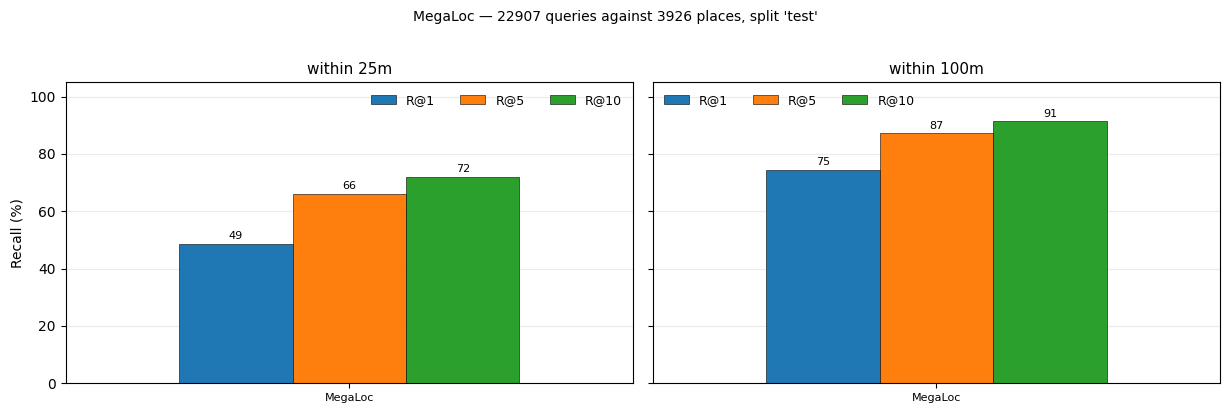

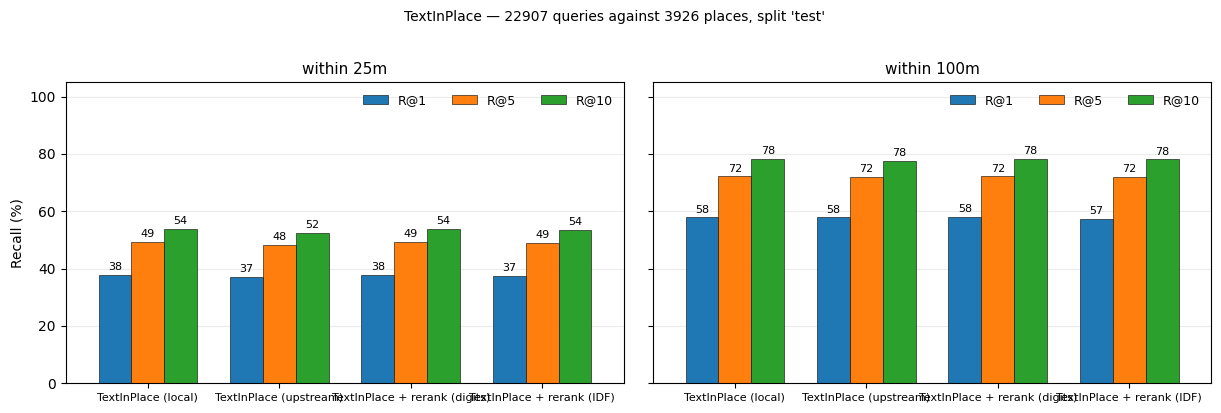

In [34]:
if RESULTS:
    for family, names in families().items():
        table = results_table(names)
        radii = table.columns.get_level_values(0).unique()
        fig, axes = plt.subplots(1, len(radii), figsize=(6.2 * len(radii), 4.0), sharey=True)
        axes = np.atleast_1d(axes)

        for ax, radius in zip(axes, radii):
            block = table[radius]
            block.plot(kind="bar", ax=ax, rot=0, edgecolor="black", linewidth=0.4, width=0.75)
            ax.set_title(radius, fontsize=11)
            ax.set_xlabel("")
            ax.set_ylim(0, 105)
            ax.grid(axis="y", alpha=0.25)
            ax.set_axisbelow(True)
            ax.legend(title=None, frameon=False, ncol=len(block.columns), fontsize=9)
            for container in ax.containers:
                ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)
            ax.tick_params(axis="x", labelsize=8)

        axes[0].set_ylabel("Recall (%)")
        fig.suptitle(f"{family} — {split_caption}", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()

## 6️⃣ Single-image inference demo

The photo is used the way the system is meant to be used: as an **out-of-database query**. It goes
through the real `LateFusionOrchestrator` when OCR is enabled, otherwise straight through the
visual retriever, and the conditional RANSAC verifier gets the last word on whether a GPS fix is
emitted at all.

Note the database used here is the *test* split built in section 1, so a photo taken outside that
area will legitimately produce a low-confidence answer — which is exactly what the kill-switch is
for.

In [45]:
candidates = None
if QUERY_IMAGE.exists() and retriever is not None:
    from vpr_pipeline.fusion import RetrievalCandidate

    raw = retriever.search(QUERY_IMAGE, k=min(5, len(DB)))

    if USE_OCR_IN_DEMO:
        from vpr_pipeline.ocr import SceneTextExtractor, OllamaGeoFilter
        from vpr_pipeline.fusion import LateFusionOrchestrator

        geo_filter = OllamaGeoFilter(model="qwen3:8b", zone_description="Paris, France")
        if geo_filter.is_available():
            orchestrator = LateFusionOrchestrator(
                retriever=retriever,
                text_extractor=SceneTextExtractor(device=DEVICE, weights_path=TEXTINPLACE_WEIGHTS),
                geo_filter=geo_filter,
                base_alpha=0.7, top_k_visual=5, top_k_ocr=5,
            )
            candidates = orchestrator.run(QUERY_IMAGE)
        else:
            print("Ollama unreachable — falling back to visual-only.")

    if candidates is None:
        scores = [r["visual_score"] for r in raw]
        lo, hi = min(scores), max(scores)
        span = (hi - lo) or 1.0
        candidates = [
            RetrievalCandidate(
                rank=i, place_id=str(r["place_id"]), lat=r["lat"], lon=r["lon"],
                db_image_path=Path(r["path"]), visual_score=r["visual_score"],
                visual_score_norm=(r["visual_score"] - lo) / span,
                fused_score=(r["visual_score"] - lo) / span, alpha_used=1.0,
            )
            for i, r in enumerate(raw)
        ]

    for c in candidates:
        print(f"#{c.rank + 1}  place={c.place_id:>10s}  sim={c.visual_score:.4f}  "
              f"fused={c.fused_score:.3f}  https://maps.google.com/?q={c.lat:.6f},{c.lon:.6f}")
else:
    print("SKIPPED — query image or retriever unavailable.")

#1  place=   0:12216  sim=0.8347  fused=1.000  https://maps.google.com/?q=48.879330,2.315483
#2  place=   0:12215  sim=0.8156  fused=0.669  https://maps.google.com/?q=48.879097,2.315494
#3  place=    0:3056  sim=0.7858  fused=0.155  https://maps.google.com/?q=48.857830,2.272673
#4  place=   0:12218  sim=0.7797  fused=0.051  https://maps.google.com/?q=48.879793,2.315462
#5  place=   0:12103  sim=0.7768  fused=0.000  https://maps.google.com/?q=48.880402,2.315423


In [46]:
if candidates and USE_RANSAC_IN_DEMO:
    try:
        from vpr_pipeline.geometric_verifier import GeometricVerifier

        verifier = GeometricVerifier(device=DEVICE, logistic_w=0.05, logistic_b=-2.0,
                                     min_confidence=0.5)
        geom = verifier.verify(QUERY_IMAGE, candidates)
        if not geom.triggered:
            # Unambiguous scores: RANSAC is deliberately not run and P(correct) is
            # returned as 1.0 by convention — inlier_count = 0 means "not measured".
            print("Not triggered — fused scores were unambiguous, RANSAC was not run.")
        else:
            print(f"Trigger        : {geom.triggered_reason}")
            print(f"RANSAC inliers : {geom.inlier_count}")
            print(f"P(correct)     : {geom.confidence:.3f}")
            if geom.kill_switch:
                print("\n[!] KILL-SWITCH — the system abstains, no GPS coordinate is emitted.")
            else:
                print("\nTop-1 validated by local geometry.")
    except ImportError as exc:
        print(f"SKIPPED — {exc} (pip install lightglue)")

Not triggered — fused scores were unambiguous, RANSAC was not run.


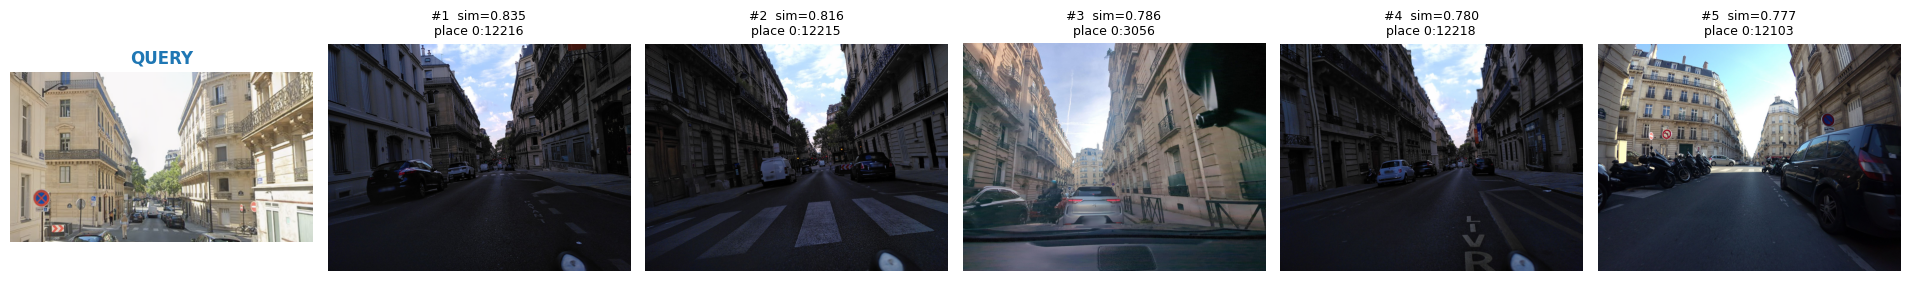

In [47]:
if candidates:
    fig, axes = plt.subplots(1, len(candidates) + 1, figsize=(3.2 * (len(candidates) + 1), 4))
    axes[0].imshow(Image.open(QUERY_IMAGE).convert("RGB"))
    axes[0].set_title("QUERY", color="tab:blue", fontweight="bold")
    axes[0].axis("off")

    for ax, c in zip(axes[1:], candidates):
        ax.imshow(Image.open(c.db_image_path).convert("RGB"))
        ax.set_title(f"#{c.rank + 1}  sim={c.visual_score:.3f}\nplace {c.place_id}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Map of the retrieved locations

Where the candidates actually are matters more than their similarity scores: five candidates
scattered across the city means the retrieval is guessing, while five clustered on one street
corner means it is confident even if the top-1 is off by one building.

The query's own position comes from `QUERY_TRUE_LATLON` in section 0, or from the image EXIF when
it survived (a PNG conversion strips it, which is the case for `IMG_0733.png`). When it is known,
the error distance to the top-1 is printed and drawn.

The map is interactive when `folium` is installed (`pip install folium`) and is also written to
`vpr_inference_map.html`; otherwise a plain metric scatter plot is drawn, which needs no extra
dependency and no network access.

In [48]:
def exif_latlon(image_path):
    """Return (lat, lon) from EXIF GPS tags, or None when absent/stripped."""
    from PIL import ExifTags

    exif = Image.open(image_path).getexif()
    gps = exif.get_ifd(ExifTags.IFD.GPSInfo) if exif else None
    if not gps:
        return None

    def to_deg(dms, ref):
        d, m, s = (float(x) for x in dms)
        value = d + m / 60 + s / 3600
        return -value if ref in ("S", "W") else value

    try:
        return (to_deg(gps[2], gps[1]), to_deg(gps[4], gps[3]))
    except (KeyError, TypeError, ValueError):
        return None


query_latlon = QUERY_TRUE_LATLON or (exif_latlon(QUERY_IMAGE) if QUERY_IMAGE.exists() else None)

if candidates:
    if query_latlon:
        err = haversine_m(query_latlon[0], query_latlon[1], candidates[0].lat, candidates[0].lon)
        print(f"Query ground truth : {query_latlon[0]:.6f}, {query_latlon[1]:.6f}")
        print(f"Top-1 error        : {err:,.0f} m")
    else:
        print("Query position unknown (no EXIF GPS, QUERY_TRUE_LATLON not set) — "
              "candidates are mapped on their own.")

    spread = max(
        haversine_m(candidates[0].lat, candidates[0].lon, c.lat, c.lon) for c in candidates
    ) if len(candidates) > 1 else 0.0
    print(f"Candidate spread   : {spread:,.0f} m between top-1 and the furthest candidate")

Query position unknown (no EXIF GPS, QUERY_TRUE_LATLON not set) — candidates are mapped on their own.
Candidate spread   : 3,940 m between top-1 and the furthest candidate


In [49]:
if candidates:
    lats = [c.lat for c in candidates] + ([query_latlon[0]] if query_latlon else [])
    lons = [c.lon for c in candidates] + ([query_latlon[1]] if query_latlon else [])
    center = (float(np.mean(lats)), float(np.mean(lons)))

    try:
        import folium

        fmap = folium.Map(location=center, zoom_start=16, tiles="OpenStreetMap")
        for c in candidates:
            top = c.rank == 0
            folium.Marker(
                [c.lat, c.lon],
                tooltip=f"#{c.rank + 1} — place {c.place_id}",
                popup=folium.Popup(
                    f"<b>#{c.rank + 1}</b><br>place {c.place_id}"
                    f"<br>sim {c.visual_score:.4f}<br>fused {c.fused_score:.3f}"
                    f"<br>{c.lat:.6f}, {c.lon:.6f}", max_width=250),
                icon=folium.Icon(color="green" if top else "lightblue",
                                 icon="star" if top else "info-sign"),
            ).add_to(fmap)

        # Always mark the input, even without a known ground truth: fall back to the
        # top-1 candidate's position so the map never silently omits the query.
        if query_latlon:
            input_pos, input_label = query_latlon, "INPUT (ground truth)"
        else:
            input_pos = (candidates[0].lat, candidates[0].lon)
            input_label = "INPUT (no ground truth — shown at top-1 estimate)"

        folium.Marker(input_pos, tooltip=input_label,
                      icon=folium.Icon(color="red", icon="camera")).add_to(fmap)

        if query_latlon:
            folium.PolyLine([query_latlon, (candidates[0].lat, candidates[0].lon)],
                            color="red", weight=2, dash_array="6").add_to(fmap)
            folium.Circle(query_latlon, radius=25, color="red", fill=True,
                          fill_opacity=0.08, tooltip="25 m — pipeline correctness radius").add_to(fmap)

        fmap.fit_bounds([[min(lats), min(lons)], [max(lats), max(lons)]], padding=(40, 40))
        fmap.save("vpr_inference_map.html")
        print("Saved to vpr_inference_map.html")
        display(fmap)

    except ImportError:
        # Offline fallback: local metric frame centred on the top-1 candidate
        lat0 = center[0]
        mx = lambda lon: (lon - center[1]) * 111_320 * np.cos(np.radians(lat0))
        my = lambda lat: (lat - center[0]) * 111_320

        fig, ax = plt.subplots(figsize=(7, 7))
        for c in candidates:
            top = c.rank == 0
            ax.scatter(mx(c.lon), my(c.lat), s=190 if top else 110,
                       c="tab:green" if top else "tab:blue",
                       marker="*" if top else "o", edgecolor="black", zorder=3)
            ax.annotate(f"#{c.rank + 1}", (mx(c.lon), my(c.lat)),
                        textcoords="offset points", xytext=(8, 6), fontsize=9)

        # Same fallback as the folium branch: always plot the input, even when its
        # true position is unknown (shown at the top-1 estimate instead).
        if query_latlon:
            qx, qy = mx(query_latlon[1]), my(query_latlon[0])
            input_label = "query (ground truth)"
        else:
            qx, qy = mx(candidates[0].lon), my(candidates[0].lat)
            input_label = "query (no ground truth — top-1 estimate)"
        ax.scatter(qx, qy, s=220, c="tab:red", marker="X", edgecolor="black",
                   zorder=4, label=input_label)
        if query_latlon:
            ax.plot([qx, mx(candidates[0].lon)], [qy, my(candidates[0].lat)],
                    "--", color="tab:red", lw=1.2, zorder=2)
            ax.add_patch(plt.Circle((qx, qy), 25, color="tab:red", alpha=0.10, zorder=1))
        ax.legend(frameon=False, loc="best")

        ax.set_aspect("equal")
        ax.set_xlabel("metres east of centre")
        ax.set_ylabel("metres north of centre")
        ax.set_title("Retrieved locations (green ★ = top-1)")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
        print("pip install folium for an interactive OpenStreetMap version.")

Saved to vpr_inference_map.html


## 7️⃣ On "training with this photo"

A single image **cannot** be trained on in this setup, and the reason is structural rather than
practical: both fine-tuning scripts sample `img_per_place=4` images per place and optimise a
Multi-Similarity Loss, which needs several *positives* of the same place plus *negatives* from
other places inside the batch to mine anything at all. One photo yields one place with one view:
the loss has nothing to contrast, and the gradient is degenerate. That is also why
`build_intern_dataset.py export` defaults to `--min-imgs 4`.

The two things that *are* meaningful with a one-off photo:

1. **Use it as a query** — section 6 above, which is what the photo is for.
2. **Add it to the database** — if you know its GPS position, append a row to the GSV-Cities CSV
   with the naming convention from the [root README](README.md), and it becomes retrievable.
   Collect ≥ 4 views of the same spot and it becomes a *trainable* place.

The cell below is a **smoke test**, not training: it runs a handful of real fine-tuning steps on
the train split to prove the loop, the loss and the optimiser are wired correctly, and prints the
loss trace. For real fine-tuning use `MegaLoc_finetuning.py` (see [MegaLoc/README.md](MegaLoc/README.md)).

In [40]:
RUN_TRAIN_SMOKE_TEST = True  # set to True to run a few training steps on a handful of places

if RUN_TRAIN_SMOKE_TEST and megaloc is not None:
    import random

    loss_mod = load_module(REPO_ROOT / "MegaLoc" / "lib" / "loss.py", "vpr_nb_loss")

    N_STEPS = 5
    PLACES_PER_BATCH = 4
    IMG_PER_PLACE = 4

    train_transform = T.Compose([
        T.Resize((224, 224)),
        T.RandAugment(num_ops=2, magnitude=9),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Places holding enough views to form positives — the whole point of the protocol.
    specs = gsv.discover_csvs(str(DATASET_ROOT), split="train")
    csv_path, img_dir = specs[0]
    df = pd.read_csv(csv_path, dtype={"panoid": str})
    groups = [g for _, g in df.groupby("place_id") if len(g) >= IMG_PER_PLACE]
    print(f"{len(groups)} places with >= {IMG_PER_PLACE} views")

    model = load_megaloc(MEGALOC_WEIGHTS, DEVICE, use_fp16=False)
    model.train()
    for p in model.parameters():
        p.requires_grad = False
    for block in model.backbone.blocks[-4:]:
        for p in block.parameters():
            p.requires_grad = True
    for p in model.backbone.norm.parameters():
        p.requires_grad = True
    for p in model.aggregator.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-3)
    criterion = loss_mod.MultiSimilarityLoss()

    trace = []
    for step in range(N_STEPS):
        imgs, labels = [], []
        for label, group in enumerate(random.sample(groups, PLACES_PER_BATCH)):
            rows = group.sample(IMG_PER_PLACE)
            for _, row in rows.iterrows():
                path = gsv.resolve_image_path(img_dir, row)
                if path is None:
                    continue
                imgs.append(train_transform(Image.open(path).convert("RGB")))
                labels.append(label)

        batch = torch.stack(imgs).to(DEVICE)
        labels_t = torch.tensor(labels, device=DEVICE)

        optimizer.zero_grad()
        loss = criterion(model(batch), labels_t)
        loss.backward()
        optimizer.step()
        trace.append(loss.item())
        print(f"  step {step + 1}/{N_STEPS}  loss = {loss.item():.4f}")

    print(f"\nLoss trace: {[round(x, 4) for x in trace]}")
    print("Smoke test only — 5 steps on a handful of places changes nothing meaningful.")
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("Smoke test disabled (RUN_TRAIN_SMOKE_TEST = False).")

16077 places with >= 4 views
  step 1/5  loss = 0.5680
  step 2/5  loss = 0.6306
  step 3/5  loss = 0.6263
  step 4/5  loss = 0.5624
  step 5/5  loss = 0.5797

Loss trace: [0.568, 0.6306, 0.6263, 0.5624, 0.5797]
Smoke test only — 5 steps on a handful of places changes nothing meaningful.
